In [250]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.mixture import GaussianMixture
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss, silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


Text(0.5, 1.0, 'Weekly samples & defect ratio')

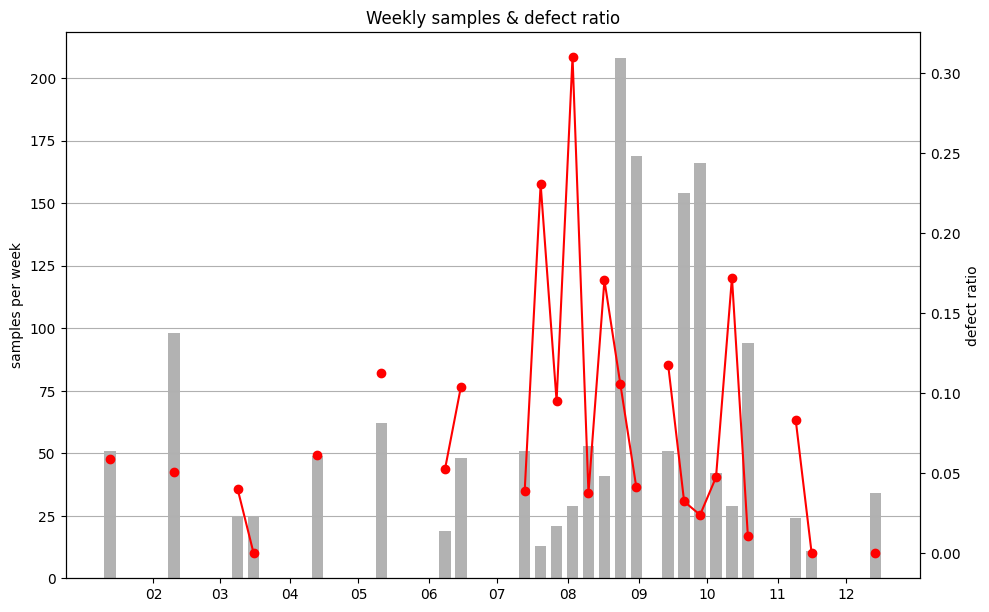

In [2]:
secom = pd.read_csv(data_path, sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

time_dt = pd.to_datetime(secom['Time'])
df = pd.DataFrame({'Time':time_dt, 'y':y}).sort_values('Time').set_index('Time')

w = df['y'].resample('W') # W means the end of the date
cnt, rate = w.size(), w.mean() # rate means 1/0 (fail/pass) less is better

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(cnt.index, cnt.values, width=5, alpha=0.3, color='k')
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y')

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker='o', color='r')
ax2.set_ylabel('defect ratio')
months = pd.date_range(rate.index.min().normalize(),
                       rate.index.max().normalize(), freq='MS') 
ax2.set_xticks(months)
ax2.set_xticklabels([d.strftime('%m') for d in months], rotation=0, ha='center')

plt.tight_layout()
plt.title('Weekly samples & defect ratio')


#### 不加入y的訊息

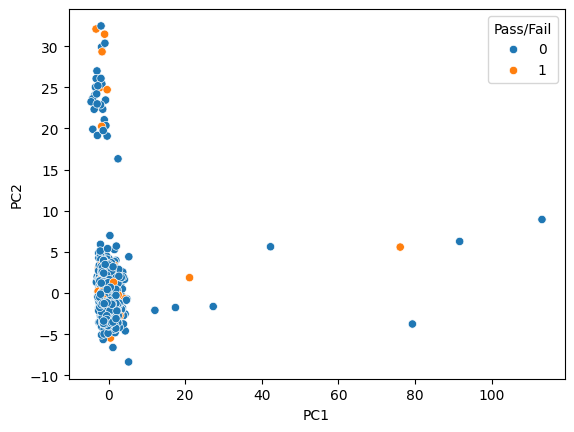

In [104]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# smote = SMOTE(k_neighbors=5, sampling_strategy=0.5)
# X_bal, y_bal = smote.fit_resample(X_imp, y)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca_df['Pass/Fail'] = y

sns.scatterplot(data = X_pca_df, x='PC1', y='PC2', hue='Pass/Fail')
plt.show()

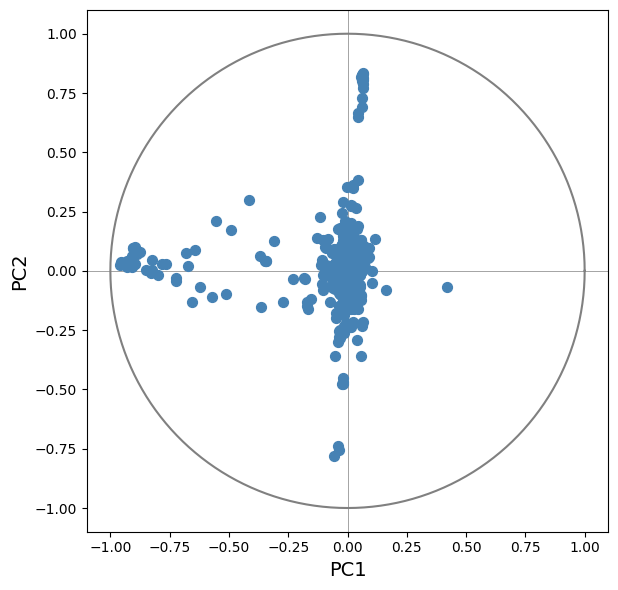

In [116]:
n, p = X_std.shape

cov_mat = np.cov(X_std.T, bias=False)
eigen_val, eigen_vec = np.linalg.eigh(cov_mat)

idx_sorted = np.argsort(eigen_val)[::-1]
lamda_ = eigen_val[idx_sorted][:2]
vector_ = eigen_vec[:, idx_sorted][:, :2]

corr = vector_ * np.sqrt(lamda_) 

theta = np.linspace(0, 2*np.pi, 361)
ucircle = np.c_[np.cos(theta), np.sin(theta)]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(ucircle[:,0], ucircle[:,1], color='grey')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)

for i, col in enumerate(X.columns):
    x, y = corr[i, 0], corr[i, 1]

    ax.scatter(x, y, color='steelblue', s=50, zorder=3)
    # x_text, y_text = x * 1.25, y * 1.25

    # ax.plot([x, x_text], [y, y_text], color='gray', linestyle='--', linewidth=0.8)

    # ax.text(x_text, y_text, col, fontsize=14, color='red',
    #         ha='center', va='center')

ax.set_xlabel(f'PC1', fontsize=14)
ax.set_ylabel(f'PC2', fontsize=14)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal', 'box')

plt.tight_layout()
plt.show()


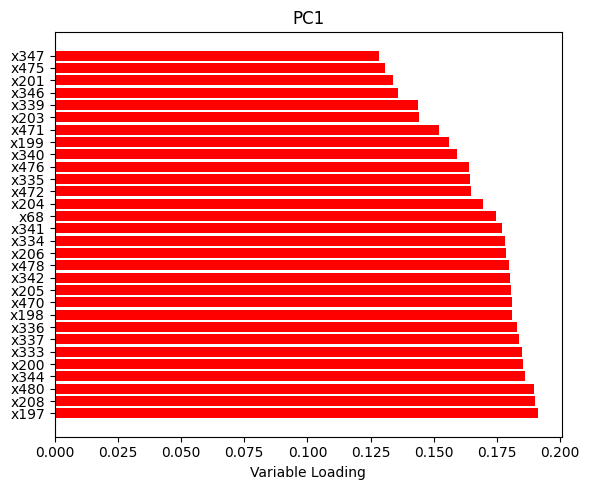

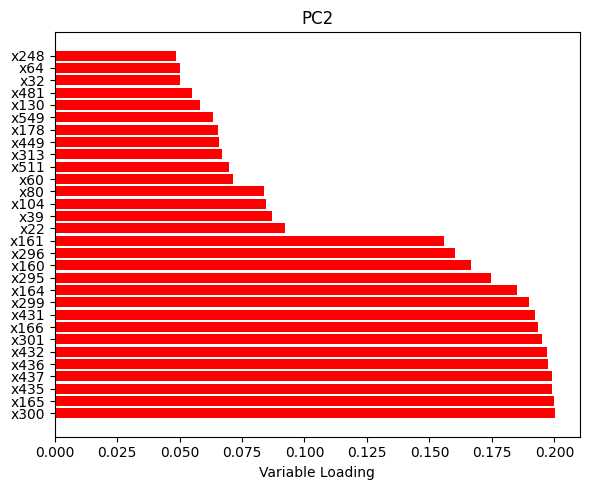

In [147]:
loading_df = pd.DataFrame(pca.components_.T,
                          columns=['PC1', 'PC2'],
                          index=X.columns)

for pc in ['PC1', 'PC2']:
    loading = loading_df[pc].sort_values(ascending=False).head(30)
    plt.figure(figsize=(6, 5))
    plt.barh(y=loading.index, width=loading.values, color='r')
    plt.axvline(0, color='gray', linestyle='--')
    plt.xlabel('Variable Loading')
    plt.title(pc)
    plt.tight_layout()
    plt.show()


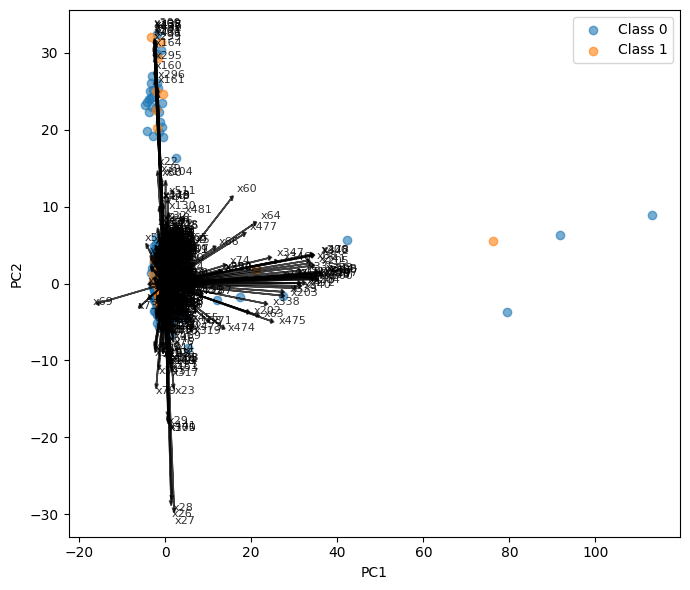

In [158]:
# --- 自動計算箭頭尺度，讓向量顯著可見 ---
# 1) 以 PCA 分數的尺度放大 loading（同一座標系）
#    注意：X_std 已標準化，因此 PC_j 的 std = sqrt(explained_variance_[j])
pc_std = np.sqrt(pca.explained_variance_[:2])            # (2,)
loadings = pca.components_.T[:, :2] * pc_std             # (p, 2) 變成與 scores 同量綱

# 2) 把最長向量的長度壓到圖面範圍的 90%
x_range = X_pca[:, 0].max() - X_pca[:, 0].min()
y_range = X_pca[:, 1].max() - X_pca[:, 1].min()
# 以較小的軸向範圍當作參考，避免超出
target = 0.90 * min(x_range, y_range)

max_vec_len = np.sqrt((loadings[:, 0]**2 + loadings[:, 1]**2)).max()
scale = (target / max_vec_len) if max_vec_len > 0 else 1.0

loadings_scaled = loadings * scale

fig, ax = plt.subplots(figsize=(7, 6))

for label in [0, 1]:
    subset = X_pca_df[X_pca_df['Pass/Fail'] == label]
    ax.scatter(subset['PC1'], subset['PC2'], alpha=0.6, label=f'Class {label}')

# abs_order = np.argsort(np.linalg.norm(loadings, axis=1))[::-1][:20]

for i, var in enumerate(X.columns):
    x, y = loadings_scaled[i, 0], loadings_scaled[i, 1]
    ax.arrow(0, 0, x, y, color='black', alpha=0.75,
             head_width=0.6, head_length=0.6, linewidth=1.2, length_includes_head=True)
    ax.text(x * 1.05, y * 1.05, X.columns[i], fontsize=8, alpha=0.8)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()

---
---

#### 加入並調整y的權重, 權重愈大, 愈容易將y=0/1分開

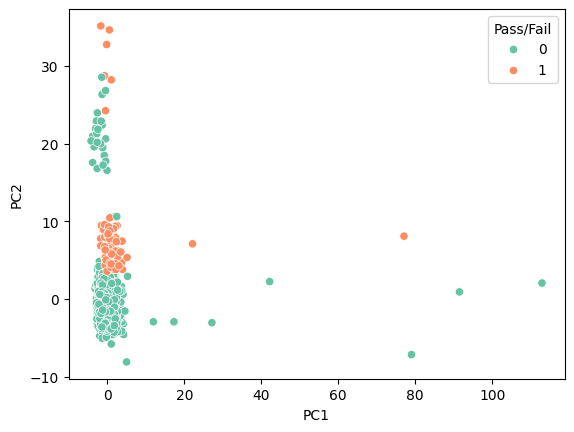

In [69]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

X = pd.concat([X_std, y*15], axis=1)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca_df['Pass/Fail'] = y

sns.scatterplot(data=X_pca_df, x='PC1', y='PC2', hue='Pass/Fail', palette='Set2')
plt.show()

---
---

#### 加入logistic預測y的訊息

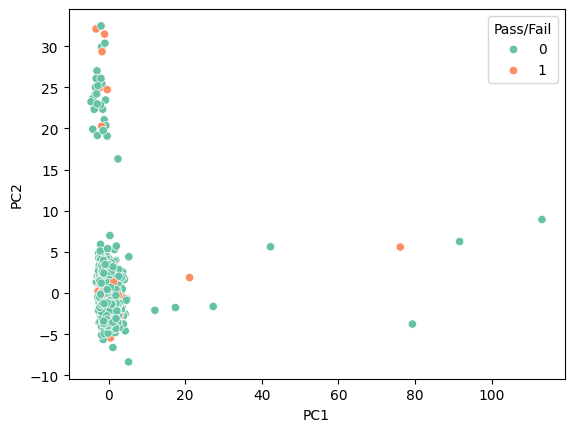

In [93]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)
p_hat = LogisticRegression(max_iter=1000, class_weight='balanced').fit(X_std, y).predict_proba(X_std)[:,1]

X_log = pd.concat([X_std, pd.Series(p_hat, name='p_hat')], axis=1)
pca = PCA(n_components=2)
X_log_pca = pca.fit_transform(X_log)

X_log_pca_df = pd.DataFrame(X_log_pca, columns=['PC1', 'PC2'])
X_log_pca_df['Pass/Fail'] = y

sns.scatterplot(data=X_log_pca_df, x='PC1', y='PC2', hue='Pass/Fail', palette='Set2')
plt.show()

---
---

#### 只有kmeans, 但認為分不好

In [247]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:1, 1:0}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

cand_k = range(2, 9)
sil = []
for k in cand_k:
    lab = KMeans(n_clusters=k, n_init=50, random_state=42).fit_predict(X_std)
    sil.append(silhouette_score(X_std, lab))
best_k = cand_k[int(np.argmax(sil))]
print('silhouette by k:', dict(zip(cand_k, np.round(sil,3))), '→ best_k =', best_k)

kmeans = KMeans(n_clusters=2, n_init=100, random_state=42)
labels = kmeans.fit_predict(X_std)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=X_std.columns)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)


silhouette by k: {2: 0.711, 3: 0.031, 4: 0.035, 5: 0.033, 6: 0.025, 7: 0.03, 8: 0.033} → best_k = 2
cluster sizes: {0: 5, 1: 1562}
cluster  0     1
y               
0        1   103
1        4  1459


PCA + KMEANS

In [246]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')

kmeans = KMeans(n_clusters=2, n_init=100, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


加入y的訊息+KMEANS

In [242]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:1, 1:0}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

# 1) 決定 y 權重
pi = y.mean()
var_y = max(pi*(1-pi), 1e-12)

r = 0.1  # 讓 y 佔總變異 10%（則 w = r/(1-r)*p）
w = (r/(1-r)) * X_std.shape[1]
c = np.sqrt(w / var_y)

# 2) 把 y 加進去（不要再對整體重標準化）
X_aug = pd.concat([X_std, pd.Series(c*y.values, index=X_std.index, name='y_w')], axis=1)

kmeans = KMeans(n_clusters=2, n_init=100, random_state=42)
labels = kmeans.fit_predict(X_aug)

centers = pd.DataFrame(kmeans.cluster_centers_, columns=X_aug.columns)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

cluster sizes: {0: 104, 1: 1463}
cluster    0     1
y                 
0        104     0
1          0  1463


---
---

GMM

In [248]:
secom = pd.read_csv(r'C:\Users\User\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:1, 1:0}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

gmm = GaussianMixture(n_components=2, random_state=42).fit(X_std)
labels = gmm.predict(X_std)
proba  = gmm.predict_proba(X_std)

df = pd.DataFrame({'y': y.values, 'label': labels})
ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

cluster    0    1
y                
0         61   43
1        680  783


---
---

In [ ]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

kb = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
Xb = pd.DataFrame(kb.fit_transform(X_std), columns=X_std.columns, index=X_std.index).astype(int)

docs = [' '.join([f'{col}_b{val}' for col, val in row.items()]) for _, row in Xb.iterrows()]
cv = CountVectorizer()
Xbow = cv.fit_transform(docs)

lda = LatentDirichletAllocation(n_components=2, learning_method='batch', random_state=42)
Theta = lda.fit_transform(Xbow)   # 每筆的topic混合 (n×K)
Phi = lda.components_           # 每topic的詞權重 (K×V)


c:\Users\USER\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 86 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 87 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 91 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:322: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 92 are removed. Consider decreasing the number of bins.
  warnings.warn(
c:\Users\USER\anaconda3\Lib\site-packages\sklearn\preprocessing\_discret

In [262]:
Theta

array([[0.07534124, 0.92465876],
       [0.24176995, 0.75823005],
       [0.35033906, 0.64966094],
       ...,
       [0.75109273, 0.24890727],
       [0.99756402, 0.00243598],
       [0.99684008, 0.00315992]])

In [263]:
Phi

array([[ 83.78664204,  68.82898148,  89.62885255, ...,  49.24874769,
         61.32819497,  86.92233915],
       [ 67.21335796,  84.17101852,  71.37114745, ..., 107.75125231,
         97.67180503,  71.07766085]])